# **TFM DATA SCIENCE**
# **Asistente Clínico Inteligente para la Predicción de Reingresos Hospitalarios en Pacientes Diabéticos mediante Machine Learning e Inteligencia Artificial**

## Introducción

La diabetes mellitus constituye una de las enfermedades crónicas con mayor impacto sanitario a nivel mundial. Los pacientes diabéticos presentan una elevada probabilidad de sufrir complicaciones clínicas que pueden derivar en nuevas hospitalizaciones poco tiempo después del alta.

La identificación temprana de pacientes con alto riesgo de reingreso permitiría optimizar el seguimiento clínico, priorizar recursos asistenciales y mejorar la calidad de la atención sanitaria.

En este proyecto se desarrolla un modelo predictivo basado en técnicas de Machine Learning capaz de estimar el riesgo de reingreso hospitalario en pacientes diabéticos utilizando información clínica, demográfica y administrativa obtenida durante el episodio de hospitalización.

## Objetivos

### Objetivo general

Desarrollar un sistema inteligente capaz de predecir el riesgo de reingreso hospitalario en pacientes diabéticos dentro de los 30 días posteriores al alta.

### Objetivos específicos

- Analizar y comprender el conjunto de datos clínicos.
- Identificar variables asociadas al riesgo de reingreso.
- Construir modelos predictivos basados en Machine Learning.
- Optimizar el rendimiento mediante técnicas avanzadas de ingeniería de características y optimización de hiperparámetros.
- Interpretar los resultados utilizando técnicas de Explainable AI.
- Integrar el modelo en una aplicación clínica interactiva desarrollada en Streamlit.

## Producto Mínimo Viable (MVP)

El MVP del proyecto consistirá en una aplicación web desarrollada mediante Streamlit capaz de:

1. Introducir los datos clínicos de un paciente.
2. Calcular automáticamente la probabilidad de reingreso hospitalario.
3. Clasificar el riesgo como bajo o alto.
4. Mostrar explicaciones interpretables mediante SHAP.
5. Incorporar un asistente basado en Inteligencia Artificial para ayudar al profesional sanitario en la interpretación de los resultados.

Para alcanzar este objetivo se desarrollarán dos fases:
- Fase 1: Construcción y validación del modelo predictivo.
- Fase 2: Desarrollo de la interfaz clínica interactiva y del asistente inteligente.

## **FASE 1: Construcción y validación del modelo predictivo**

## **Bloque A Fase 1: Carga, limpieza y EDA**

## Instalación y carga de librerías

En esta sección se importan y se cargan las librerías necesarias para la manipulación de datos, análisis estadístico y visualización gráfica.

In [ ]:
!pip install catboost optuna shap imbalanced-learn --quiet

# Datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Warnings
import warnings
warnings.filterwarnings("ignore")

# ML
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# PCA y Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Balanceo
from imblearn.over_sampling import SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Interpretabilidad
import shap

# Optimización
import optuna

# Guardado
import joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.2 MB/s eta 0:00:00


## Carga dataset y csv

El conjunto de datos contiene información clínica, administrativa y demográfica de pacientes diabéticos hospitalizados. El objetivo será predecir si un paciente volverá a ingresar en el hospital en un periodo inferior a 30 días tras el alta.

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("diabetic_data.csv")
print(df.shape)
display(df.head())

Saving diabetic_data.csv to diabetic_data.csv
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Información general

El análisis preliminar permite identificar el número de variables disponibles, los tipos de datos presentes y la existencia de posibles valores ausentes que deberán ser tratados durante el preprocesado.

In [ ]:
print(df.info())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Construcción variable objetivo

La variable original de reingreso se transforma en una variable binaria donde el valor 1 indica reingreso hospitalario en menos de 30 días y el valor 0 representa el resto de situaciones.

In [ ]:
# Target binario

df["readmitted_binary"] = (
    df["readmitted"] == "<30"
).astype(int)

print(df.shape)

df["readmitted_binary"].value_counts(normalize=True)*100

(101766, 51)


,proportion
readmitted_binary,
0,88.840084
1,11.159916


## Distribución de la variable objetivo

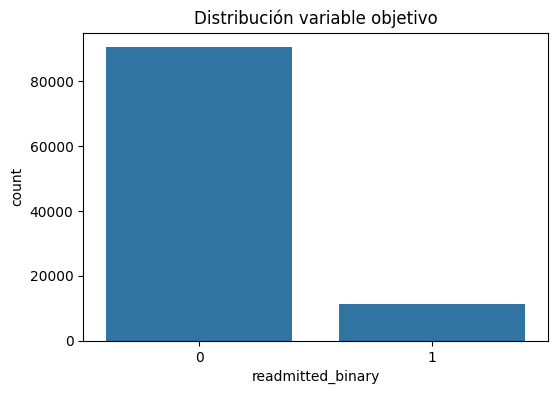

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
readmitted_binary
0    88.84
1    11.16
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="readmitted_binary",
    data=df
)

plt.title(
    "Distribución variable objetivo"
)

plt.show()

print(
    df["readmitted_binary"]
    .value_counts()
)

print(
    round(
        df["readmitted_binary"]
        .value_counts(normalize=True)*100,
        2
    )
)

## Limpieza de datos

Los valores desconocidos representados mediante el símbolo "?" se transforman en valores nulos estándar de Python para facilitar su posterior tratamiento.

In [ ]:
df = df.replace("?", np.nan)

# eliminar identificadores

df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "readmitted"
    ],
    inplace=True
)

display(
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
time_in_hospital,0


## Variables numéricas iniciales

Estas variables representan indicadores clínicos relacionados con la utilización de recursos hospitalarios, procedimientos diagnósticos, carga terapéutica e historial asistencial del paciente.

In [ ]:
candidate_vars = [

    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"

]

## KPI's principales

Los indicadores principales permiten obtener una visión general de la población estudiada y del nivel medio de complejidad clínica de los pacientes incluidos en el análisis.

In [ ]:
print("\n================ KPIs =================")

print(
    "Número pacientes:",
    len(df)
)

print(
    "Tasa reingreso:",
    round(
        df["readmitted_binary"]
        .mean()*100,
        2
    ),
    "%"
)

print(
    "Media estancia:",
    round(
        df["time_in_hospital"]
        .mean(),
        2
    )
)

print(
    "Media medicamentos:",
    round(
        df["num_medications"]
        .mean(),
        2
    )
)

print(
    "Media ingresos previos:",
    round(
        df["number_inpatient"]
        .mean(),
        2
    )
)


================ KPIs =================
Número pacientes: 101766
Tasa reingreso: 11.16 %
Media estancia: 4.4
Media medicamentos: 16.02
Media ingresos previos: 0.64


## Distribuciones y outliers

Los histogramas permiten estudiar la forma de la distribución de cada variable, mientras que los diagramas de caja facilitan la identificación de valores extremos y posibles observaciones atípicas.

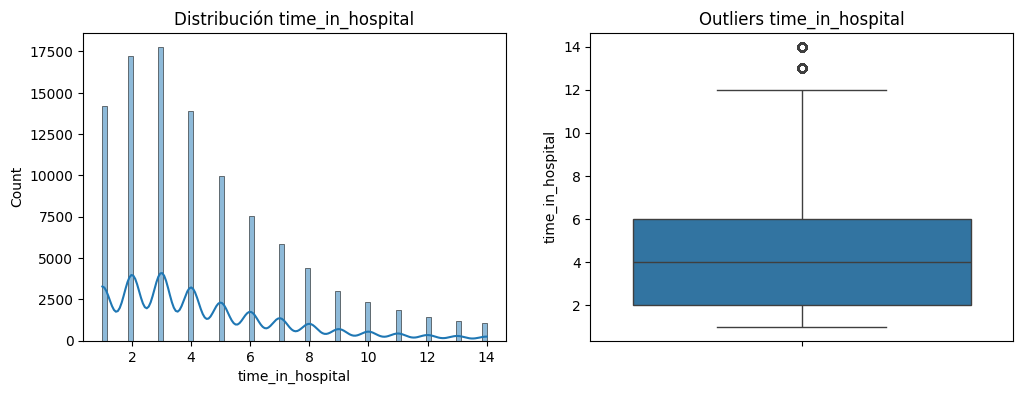

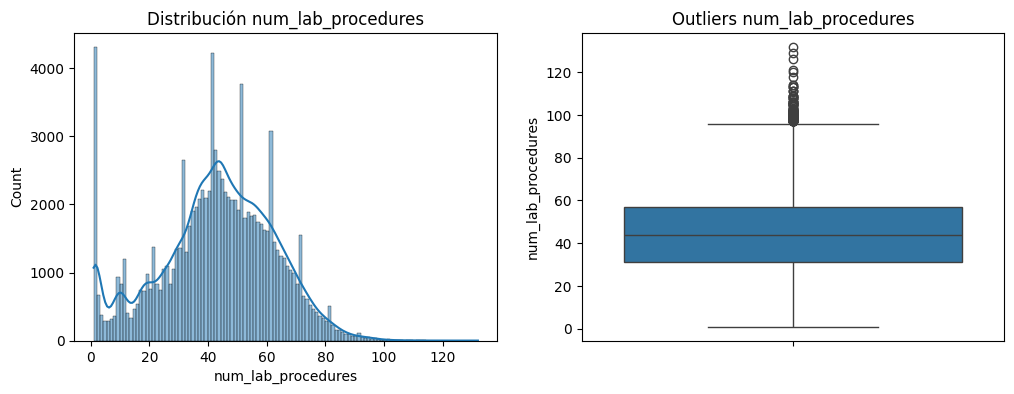

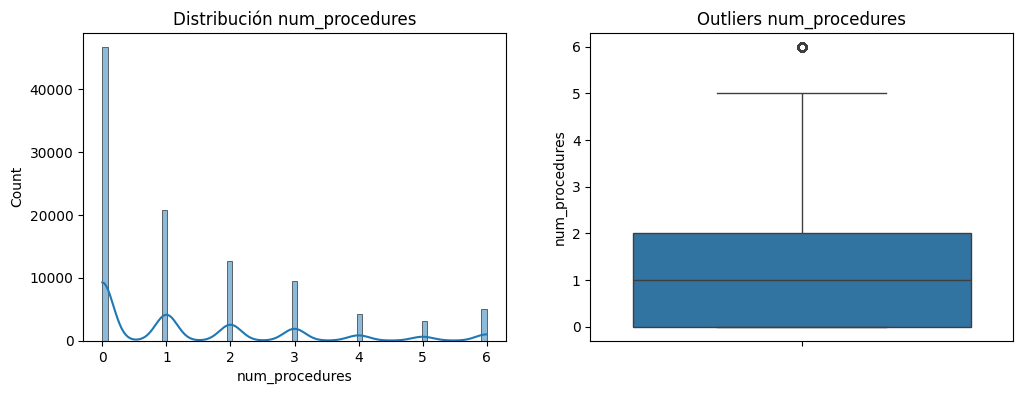

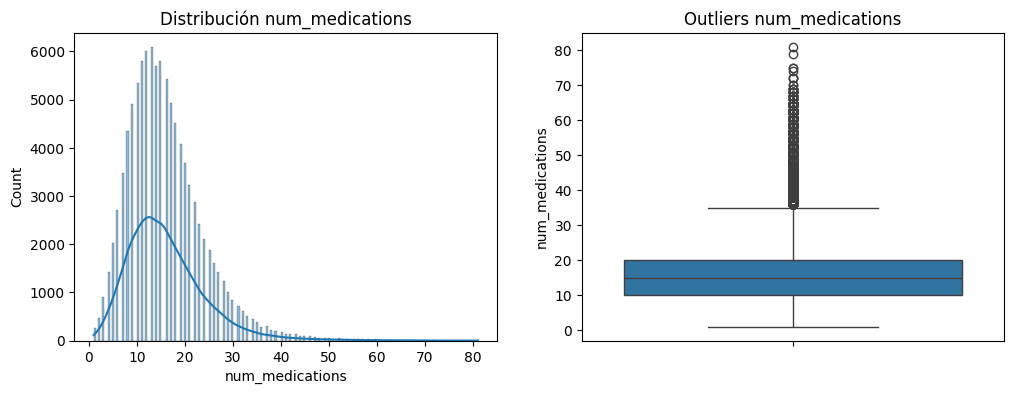

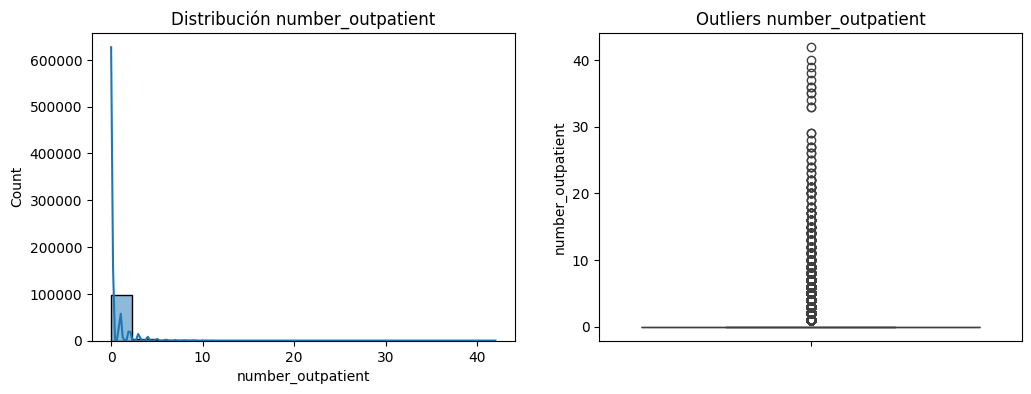

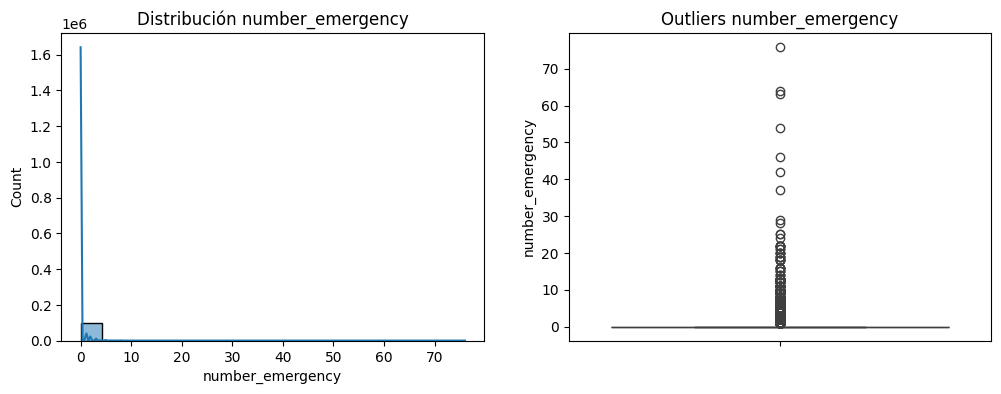

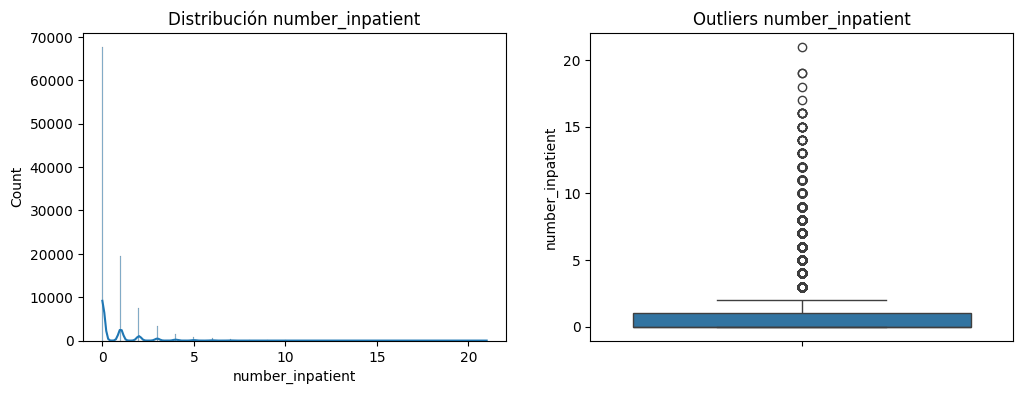

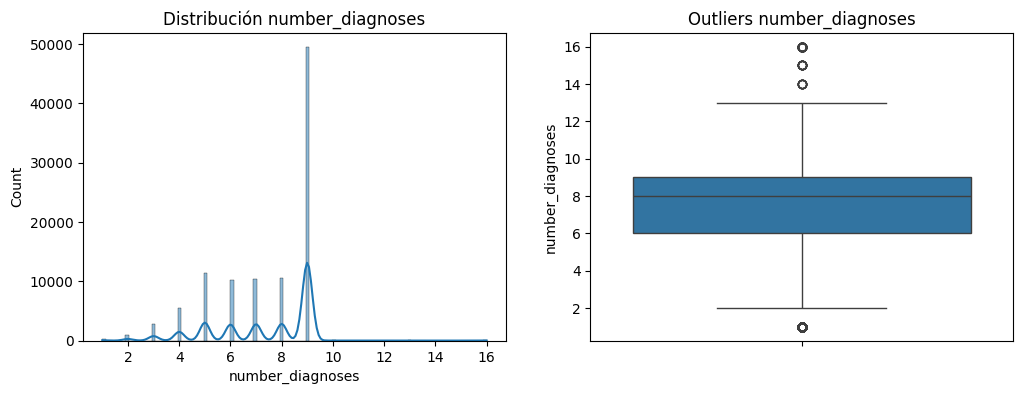

In [ ]:
for var in candidate_vars:

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(12,4)
    )

    sns.histplot(
        df[var],
        kde=True,
        ax=ax[0]
    )

    ax[0].set_title(
        f"Distribución {var}"
    )

    sns.boxplot(
        y=df[var],
        ax=ax[1]
    )

    ax[1].set_title(
        f"Outliers {var}"
    )

    plt.show()

## Análisis por edad

La población analizada se concentra principalmente en grupos de edad avanzados, coherentemente con la epidemiología habitual de la diabetes tipo 2.

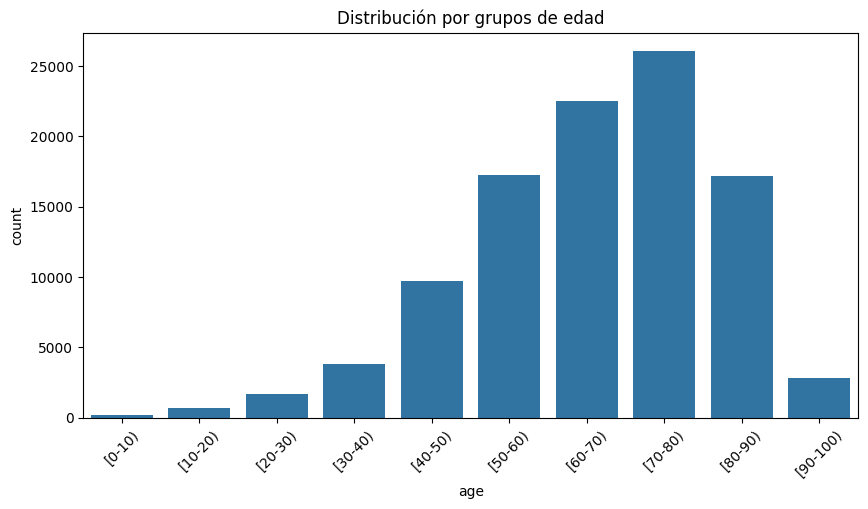

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="age",
    data=df
)

plt.xticks(rotation=45)

plt.title(
    "Distribución por grupos de edad"
)

plt.show()

## Reingreso por edad

Este análisis permite estudiar cómo varía la tasa de reingreso entre los distintos grupos de edad y evaluar la posible influencia del envejecimiento sobre el riesgo de nuevas hospitalizaciones.

In [ ]:
age_readmission = pd.crosstab(

    df["age"],
    df["readmitted_binary"],

    normalize="index"

)

display(age_readmission)

readmitted_binary,0,1
age,,
[0-10),0.981366,0.018634
[10-20),0.942113,0.057887
[20-30),0.857574,0.142426
[30-40),0.887682,0.112318
[40-50),0.893960,0.106040
[50-60),0.903338,0.096662
[60-70),0.888716,0.111284
[70-80),0.882269,0.117731
[80-90),0.879165,0.120835


##Matriz de correlaciones

La matriz de correlaciones permite identificar relaciones lineales entre variables y detectar posibles problemas de redundancia o multicolinealidad.

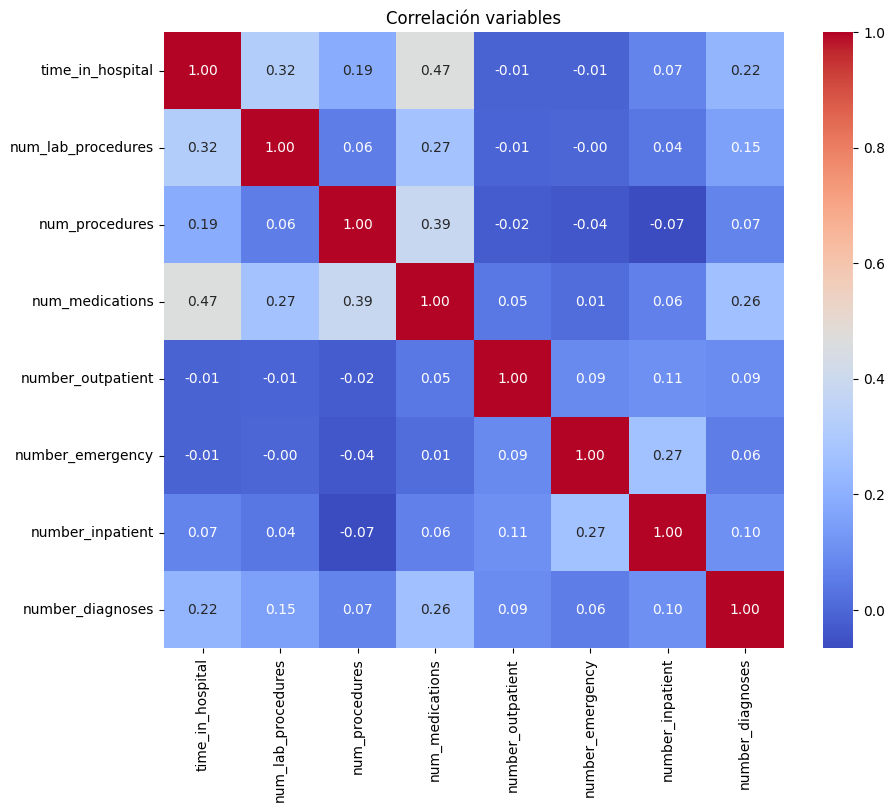

In [ ]:
plt.figure(figsize=(10,8))

corr = df[candidate_vars].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlación variables"
)

plt.show()

## **Bloque B Fase 1: Feature engineering, PCA y clustering**

## Agrupación de diagnósticos ICD

Transformar los códigos ICD originales en categorías clínicas más interpretables. Los códigos diagnósticos originales presentan miles de valores distintos. Su agrupación permite reducir dimensionalidad y generar variables clínicamente interpretables para el modelo.

In [ ]:
def group_diag_v2(code):

    try:

        code = float(code)

        if 390 <= code < 460:
            return "Circulatory"

        elif 460 <= code < 520:
            return "Respiratory"

        elif 520 <= code < 580:
            return "Digestive"

        elif 580 <= code < 630:
            return "Genitourinary"

        elif 710 <= code < 740:
            return "Musculoskeletal"

        elif 140 <= code < 240:
            return "Neoplasms"

        elif 250 <= code < 251:
            return "Diabetes"

        elif 780 <= code < 800:
            return "Symptoms"

        elif 800 <= code < 1000:
            return "Injury"

        else:
            return "Other"

    except:
        return "Other"

In [ ]:
for col in ["diag_1", "diag_2", "diag_3"]:

    df[col + "_group"] = df[col].apply(
        group_diag_v2
    )

In [ ]:
display(
    df["diag_1_group"]
    .value_counts()
)
display(
    df["diag_2_group"]
    .value_counts()
)
display(
    df["diag_3_group"]
    .value_counts()
)

,count
diag_1_group,
Circulatory,30336
Other,14980
Respiratory,10407
Digestive,9208
Diabetes,8757
Symptoms,7636
Injury,6974
Genitourinary,5078
Musculoskeletal,4957


,count
diag_2_group,
Circulatory,31365
Other,24036
Diabetes,12794
Respiratory,10251
Genitourinary,7987
Symptoms,4632
Digestive,3962
Neoplasms,2547
Injury,2428


,count
diag_3_group,
Circulatory,29918
Other,27778
Diabetes,17157
Respiratory,6774
Genitourinary,6327
Symptoms,4523
Digestive,3572
Injury,1946
Musculoskeletal,1915


## Análisis de reingreso por diagnóstico

Se observan diferencias entre grupos diagnósticos. Algunas categorías presentan mayores proporciones de reingreso, sugiriendo una asociación potencial con el riesgo clínico.

In [ ]:
for col in [

    "diag_1_group",
    "diag_2_group",
    "diag_3_group"

]:

    tabla = pd.crosstab(

        df[col],
        df["readmitted_binary"],

        normalize="index"

    )

    display(tabla)

readmitted_binary,0,1
diag_1_group,,
Circulatory,0.885483,0.114517
Diabetes,0.870161,0.129839
Digestive,0.895091,0.104909
Genitourinary,0.891887,0.108113
Injury,0.877545,0.122455
Musculoskeletal,0.904983,0.095017
Neoplasms,0.899214,0.100786
Other,0.882443,0.117557
Respiratory,0.893149,0.106851


readmitted_binary,0,1
diag_2_group,,
Circulatory,0.889622,0.110378
Diabetes,0.894169,0.105831
Digestive,0.884149,0.115851
Genitourinary,0.881432,0.118568
Injury,0.885502,0.114498
Musculoskeletal,0.899660,0.100340
Neoplasms,0.850805,0.149195
Other,0.887211,0.112789
Respiratory,0.892888,0.107112


readmitted_binary,0,1
diag_3_group,,
Circulatory,0.892941,0.107059
Diabetes,0.894329,0.105671
Digestive,0.877100,0.122900
Genitourinary,0.864075,0.135925
Injury,0.884378,0.115622
Musculoskeletal,0.893473,0.106527
Neoplasms,0.857759,0.142241
Other,0.893117,0.106883
Respiratory,0.877916,0.122084


## Feature engineering

Creamos variables derivadas capaces de capturar patrones clínicos complejos. Estas variables permiten incorporar conocimiento clínico al modelo combinando información diagnóstica, terapéutica y asistencial.

In [ ]:
# Complejidad clínica
df["clinical_complexity"] = (df["num_medications"] +df["number_diagnoses"])

# Utilización previa
df["previous_utilization"] = ( df["number_outpatient"] + df["number_emergency"]+df["number_inpatient"] )

# Intensidad hospitalaria
df["hospital_intensity"] = (df["num_lab_procedures"]+df["num_procedures"])

#Carga terapéutica
df["medication_load"] = ( df["num_medications"]*df["number_diagnoses"])

# Medicación por día
df["medication_per_day"] = ( df["num_medications"]/ (df["time_in_hospital"] + 1))

# Laboratorio por día
df["lab_per_day"] = ( df["num_lab_procedures"] / (df["time_in_hospital"] + 1))

# Diagnósticos por día
df["diagnoses_per_day"] = (df["number_diagnoses"]/ (df["time_in_hospital"] + 1))

# Paciente polimedicado
df["polypharmacy"] = (df["num_medications"] >= 10).astype(int)

# Paciente anciano
df["elderly"] = df["age"].isin([ "[70-80)", "[80-90)", "[90-100)"]).astype(int)

# Alta utilización sanitaria
df["high_utilization"] = (  df["previous_utilization"] >= 3).astype(int)

# Múltiples ingresos
df["multiple_admissions"] = (df["number_inpatient"] >= 2).astype(int)

# Historial de riesgo
df["high_risk_history"] = (df["number_inpatient"] >= 2).astype(int)

# Paciente muy complejo
df["very_complex"] = ((df["number_diagnoses"] >= 8)&( df["num_medications"] >= 15)).astype(int)

## KPI's de variables derivadas

Las nuevas variables presentan una elevada variabilidad entre pacientes y permiten capturar aspectos clínicos no representados directamente en las variables originales.

In [ ]:
derived_vars = [

    "clinical_complexity",
    "previous_utilization",
    "hospital_intensity",
    "medication_load",
    "medication_per_day",
    "lab_per_day",
    "diagnoses_per_day"

]

display(
    df[derived_vars]
    .describe()
)

,clinical_complexity,previous_utilization,hospital_intensity,medication_load,medication_per_day,lab_per_day,diagnoses_per_day
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,23.444451,1.202759,44.435371,123.033813,3.485367,9.765316,1.763026
std,8.832675,2.291781,19.846605,75.400474,1.960798,6.203734,0.984534
min,2.000000,0.000000,1.000000,1.000000,0.076923,0.066667,0.125000
25%,17.000000,0.000000,33.000000,70.000000,2.125000,5.454545,1.000000
50%,22.000000,0.000000,45.000000,108.000000,3.000000,8.666667,1.500000
75%,28.000000,2.000000,58.000000,162.000000,4.333333,13.000000,2.250000
max,87.000000,80.000000,135.000000,1040.000000,21.000000,55.500000,8.000000


## Análisis de componentes principales (PCA)

Reducir dimensionalidad y visualizar la estructura global del conjunto de pacientes. El PCA permite representar los pacientes en un espacio bidimensional. Aunque se observan ciertas agrupaciones naturales, no existe una separación perfectamente definida entre pacientes con y sin reingreso.

In [ ]:
pca_vars = [

    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",

    "clinical_complexity",
    "previous_utilization",
    "hospital_intensity",
    "medication_load",
    "medication_per_day",
    "lab_per_day",
    "diagnoses_per_day"

]

In [ ]:
# Escalado
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[pca_vars]
)

In [ ]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    X_scaled
)

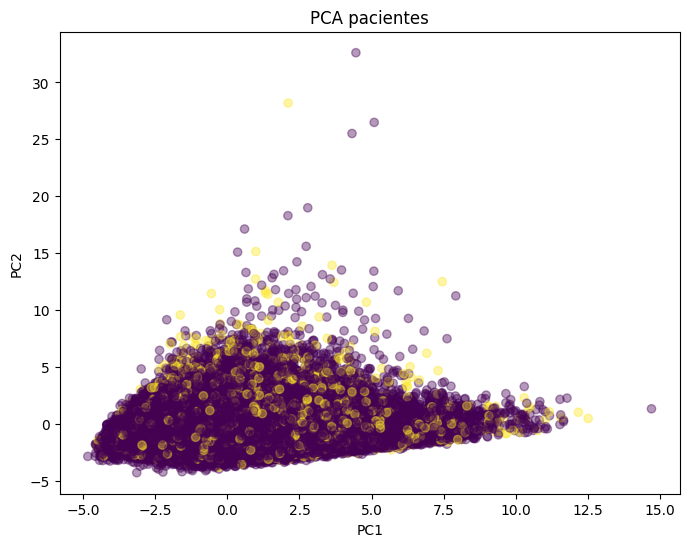

In [ ]:
# Visualización
plt.figure(figsize=(8,6))

plt.scatter(

    pca_result[:,0],

    pca_result[:,1],

    c=df["readmitted_binary"],

    alpha=0.4

)

plt.title(
    "PCA pacientes"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
# Varianza explicada
print(
    pca.explained_variance_ratio_
)

[0.27942151 0.16587566]


## Loadings PCA

Los loadings permiten interpretar qué variables contribuyen en mayor medida a cada componente principal.

In [ ]:
loadings = pd.DataFrame(

    pca.components_.T,

    columns=[
        "PC1",
        "PC2"
    ],

    index=pca_vars

)

display(loadings)

,PC1,PC2
time_in_hospital,0.330836,-0.361998
num_lab_procedures,0.244570,-0.007391
num_procedures,0.204798,-0.013256
num_medications,0.440597,0.060379
number_outpatient,0.045720,0.234008
number_emergency,0.029840,0.229637
number_inpatient,0.073326,0.226255
number_diagnoses,0.228058,0.182321
clinical_complexity,0.455349,0.095472
previous_utilization,0.077802,0.347306


## Clustering

Identificamos perfiles clínicos homogéneos de pacientes.

In [ ]:
# Kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)

In [ ]:
# Ajuste
clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters

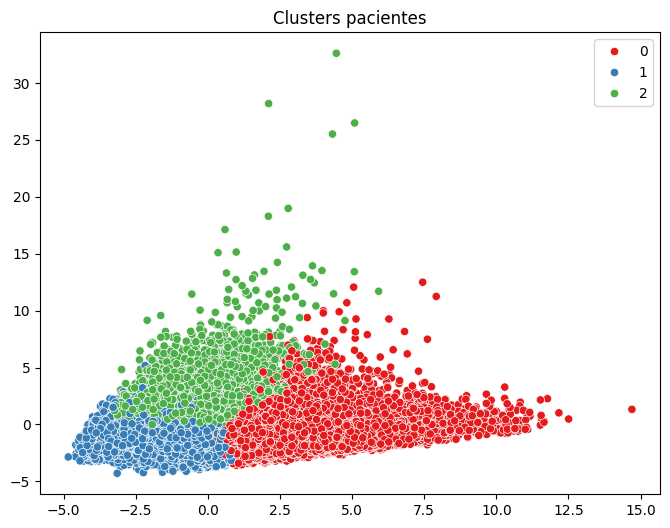

In [ ]:
# Visualización
plt.figure(figsize=(8,6))

sns.scatterplot(x=pca_result[:,0],y=pca_result[:,1],hue=clusters,palette="Set1")

plt.title("Clusters pacientes")

plt.show()

In [ ]:
# Perfil de clústers
cluster_profile = (df.groupby("cluster")[pca_vars] .mean())

display(cluster_profile)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,clinical_complexity,previous_utilization,hospital_intensity,medication_load,medication_per_day,lab_per_day,diagnoses_per_day
cluster,,,,,,,,,,,,,,,
0,7.334889,55.151807,2.134598,24.360077,0.424519,0.212260,0.808737,8.417284,32.777361,1.445515,57.286405,203.739155,3.248961,7.247698,1.129495
1,3.956524,33.227427,0.943207,11.412955,0.201675,0.105721,0.410704,6.387737,17.800691,0.718100,34.170634,73.514268,2.599496,7.506956,1.489999
2,2.058656,45.460237,1.119065,14.372941,0.561767,0.319684,0.792711,7.944783,22.317724,1.674162,46.579302,114.351281,5.038636,15.672412,2.811902


In [ ]:
# Tamaño de clústers
display(df["cluster"] .value_counts())

,count
cluster,
1,43104
0,29577
2,29085


El clustering identifica diferentes perfiles asistenciales. Algunos grupos presentan una mayor complejidad clínica, mayor número de diagnósticos y un uso más intensivo de recursos hospitalarios.

## Reingreso por clúster

La comparación de las tasas de reingreso entre clusters permite evaluar si determinados perfiles clínicos presentan un riesgo significativamente superior.

In [ ]:
cluster_readmission = pd.crosstab(df["cluster"],df["readmitted_binary"], normalize="index")

display(cluster_readmission)

readmitted_binary,0,1
cluster,,
0,0.866957,0.133043
1,0.903048,0.096952
2,0.888499,0.111501


La fase de ingeniería de características nos ha permitido enriquecer la información clínica disponible mediante la creación de variables derivadas relacionadas con complejidad asistencial, carga terapéutica y utilización previa del sistema sanitario.

Posteriormente, el análisis PCA nos ha permitido explorar la estructura global de los pacientes, mientras que el clustering ha identificado diferentes perfiles clínicos con características asistenciales diferenciadas.

Estas transformaciones constituyen la base sobre la que se desarrollará el modelo predictivo final en el siguiente bloque.

## **Bloque C Fase 1: Modelado predictivo, evaluación, shap y persistencia**

## Definición de variables finales

Seleccionamos las variables que serán utilizadas por el modelo final. Estas variables combinan información clínica, diagnóstica, farmacológica y administrativa con variables derivadas obtenidas mediante ingeniería de características.

In [ ]:
# Medicaciones
medication_cols = [

    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'acetohexamide',
    'glipizide',
    'glyburide',
    'tolbutamide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'troglitazone',
    'tolazamide',
    'examide',
    'citoglipton',
    'insulin',
    'glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone'

]

In [ ]:
# Variables finales
features = [

    # Demográficas
    "race",
    "gender",
    "age",
    "weight",

    # Administrativas
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",

    "payer_code",
    "medical_specialty",

    # Clínicas
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",

    "number_outpatient",
    "number_emergency",
    "number_inpatient",

    "number_diagnoses",

    # Laboratorio
    "max_glu_serum",
    "A1Cresult",

    # Diagnósticos
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",

    # Tratamiento
    "change",
    "diabetesMed"

] + medication_cols + [

    # Feature engineering
    "clinical_complexity",
    "previous_utilization",
    "hospital_intensity",
    "medication_load",

    "medication_per_day",
    "lab_per_day",
    "diagnoses_per_day",

    "polypharmacy",
    "elderly",

    "high_utilization",
    "multiple_admissions",

    "high_risk_history",

    "very_complex"
]

## Train / Validation / Test split

Los datos se dividen en entrenamiento (70%), validación (15%) y prueba (15%), evitando fugas de información entre fases.

In [ ]:
X = df[features]

y = df["readmitted_binary"]

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split( X,y, test_size=0.30, stratify=y, random_state=42)

X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50,  stratify=y_temp,  random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (71236, 60)
Validation: (15265, 60)
Test: (15265, 60)


## Imputación de valores ausentes

La imputación se realiza utilizando únicamente información procedente del conjunto de entrenamiento para evitar contaminación de datos.

In [ ]:
for col in X_train.columns:

    if X_train[col].dtype == "object":

        moda = X_train[col].mode()[0]

        X_train[col] = X_train[col].fillna(moda)

        X_valid[col] = X_valid[col].fillna(moda)

        X_test[col] = X_test[col].fillna(moda)

    else:

        mediana = X_train[col].median()

        X_train[col] = X_train[col].fillna(mediana)

        X_valid[col] = X_valid[col].fillna(mediana)

        X_test[col] = X_test[col].fillna(mediana)

## Variables categóricas para Catboost

CatBoost permite trabajar directamente con variables categóricas sin necesidad de aplicar One-Hot Encoding.

In [ ]:
cat_features = list( X_train.select_dtypes(include="object" ).columns)
cat_idx = [ X_train.columns.get_loc(col)for col in cat_features]
print(cat_features)

['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'change', 'diabetesMed', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


## Optimización con Optuna

Optuna realiza una búsqueda automática de hiperparámetros con el objetivo de maximizar el AUC sobre el conjunto de validación.

In [ ]:
# Importaciones
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
# Función objetivo
def objective(trial):

    model = CatBoostClassifier(
        iterations=trial.suggest_int( "iterations", 400, 1200 ),
        depth=trial.suggest_int( "depth",4, 8),
        learning_rate=trial.suggest_float( "learning_rate",0.02, 0.15),
        l2_leaf_reg=trial.suggest_float( "l2_leaf_reg",1,20),
        random_strength=trial.suggest_float( "random_strength",0,10),
        auto_class_weights="Balanced",
        eval_metric="AUC",
        random_state=42,
        verbose=0
    )

    model.fit(X_train, y_train,cat_features=cat_idx)
    pred = model.predict_proba( X_valid)[:,1]
    auc = roc_auc_score(y_valid,pred)

    return auc

In [ ]:
# Ejecución
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2026-06-01 06:51:43,150] A new study created in memory with name: no-name-71ba6e72-543f-4a11-91fd-ee1ddef3400c
[I 2026-06-01 06:59:13,153] Trial 0 finished with value: 0.6831342070069064 and parameters: {'iterations': 770, 'depth': 7, 'learning_rate': 0.04817376358093289, 'l2_leaf_reg': 2.3116650539608643, 'random_strength': 7.843884180172045}. Best is trial 0 with value: 0.6831342070069064.
[I 2026-06-01 07:04:49,879] Trial 1 finished with value: 0.6839083563643741 and parameters: {'iterations': 513, 'depth': 7, 'learning_rate': 0.042154035024435016, 'l2_leaf_reg': 10.93556760046649, 'random_strength': 5.709339295912773}. Best is trial 1 with value: 0.6839083563643741.
[I 2026-06-01 07:12:37,029] Trial 2 finished with value: 0.6822279385825064 and parameters: {'iterations': 475, 'depth': 7, 'learning_rate': 0.0733813872876847, 'l2_leaf_reg': 4.718586661663462, 'random_strength': 7.663784733306057}. Best is trial 1 with value: 0.6839083563643741.
[I 2026-06-01 07:22:47,287] Trial 3 

In [ ]:
# Resultados
print(study.best_value)
print(study.best_params)

0.6881054844169607
{'iterations': 777, 'depth': 6, 'learning_rate': 0.03907627555239178, 'l2_leaf_reg': 8.132766008054267, 'random_strength': 4.43618728367484}


## Modelo final

Sustituimos por los mejores parámetros obtenidos.

In [ ]:
best_model = CatBoostClassifier(
    iterations=777,
    depth=6,
    learning_rate=0.03907627555239178,
    l2_leaf_reg=8.132766008054267,
    random_strength=4.43618728367484,
    auto_class_weights="Balanced",
    eval_metric="AUC",
    random_state=42,
    verbose=100
)

In [ ]:
best_model.fit(X_train,y_train,cat_features=cat_idx)

0:	total: 322ms	remaining: 4m 9s
100:	total: 36s	remaining: 4m 1s
200:	total: 1m 7s	remaining: 3m 14s
300:	total: 1m 44s	remaining: 2m 45s
400:	total: 2m 35s	remaining: 2m 25s
500:	total: 3m 26s	remaining: 1m 53s
600:	total: 4m 19s	remaining: 1m 15s
700:	total: 5m 12s	remaining: 33.8s
776:	total: 5m 53s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=777, l2_leaf_reg=8.132766008054267, learning_rate=0.03907627555239178, random_state=42, random_strength=4.43618728367484, verbose=100)

CatBoost ha sido seleccionado como modelo final por ofrecer el mejor rendimiento global y una gestión nativa de variables categóricas.

## Búsqueda del threshold óptimo

El umbral se ajusta exclusivamente utilizando el conjunto de validación para evitar optimismo en la evaluación final.

In [ ]:
from sklearn.metrics import f1_score

valid_prob = best_model.predict_proba( X_valid)[:,1]

thresholds = np.arange(0.05,0.95,0.05)

threshold_results = []

for t in thresholds:

    preds = (valid_prob >= t ).astype(int)
    precision = precision_score(y_valid, preds)
    recall = recall_score(y_valid,preds)
    f1 = f1_score( y_valid, preds)
    threshold_results.append([t, precision, recall, f1])

threshold_df = pd.DataFrame(threshold_results,columns=["threshold","precision","recall","f1"])

display(threshold_df)

best_threshold = threshold_df.loc[threshold_df["f1"].idxmax(),"threshold"]

print("Best threshold:",best_threshold)

,threshold,precision,recall,f1
0,0.05,0.111643,1.000000,0.200860
1,0.10,0.112150,1.000000,0.201681
2,0.15,0.113264,0.998239,0.203445
3,0.20,0.114535,0.994718,0.205417
4,0.25,0.116960,0.981808,0.209020
5,0.30,0.123463,0.960681,0.218806
6,0.35,0.132258,0.904930,0.230787
7,0.40,0.147354,0.826878,0.250133
8,0.45,0.165928,0.724765,0.270034
9,0.50,0.187500,0.589789,0.284541


Best threshold: 0.55


## Evaluación final

In [ ]:
# Predicciones
test_prob = best_model.predict_proba(X_test)[:,1]
test_pred = ( test_prob >= best_threshold).astype(int)

In [ ]:
# Métricas
auc = roc_auc_score(y_test,test_prob)
accuracy = accuracy_score(y_test,test_pred)
precision = precision_score(y_test,test_pred)
recall = recall_score(y_test,test_pred)
f1 = f1_score(y_test,test_pred)

In [ ]:
# Resultados
print("\nRESULTADOS TEST")

print("AUC:", round(auc,4))
print("Accuracy:", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1:", round(f1,4))


RESULTADOS TEST
AUC: 0.6708
Accuracy: 0.7477
Precision: 0.1993
Recall: 0.4181
F1: 0.2699


El modelo final alcanza un AUC aproximado de 0.6708 sobre el conjunto de prueba, representando el mejor rendimiento obtenido durante el proyecto.

El modelo final obtine un AUC de 0.6708, lo que indica una capacidad de discriminación moderada y superior al azar para identificar pacientes con riesgo de reingreso. Además, alcanzó una accuracy del 74.77%, una precisión del 19.93% y un recall del 41.81%, lo que significa que es capaz de detectar aproximadamente 4 de cada 10 pacientes que realmente serán reingresados. Aunque la presencia de falsos positivos sigue siendo elevada, el modelo resulta útil como herramienta de apoyo a la decisión clínica, permitiendo identificar de forma temprana pacientes potencialmente vulnerables y facilitando la planificación de estrategias de seguimiento y prevención.

## Matriz de confusión

La matriz de confusión permite analizar los aciertos y errores cometidos por el modelo en cada clase.

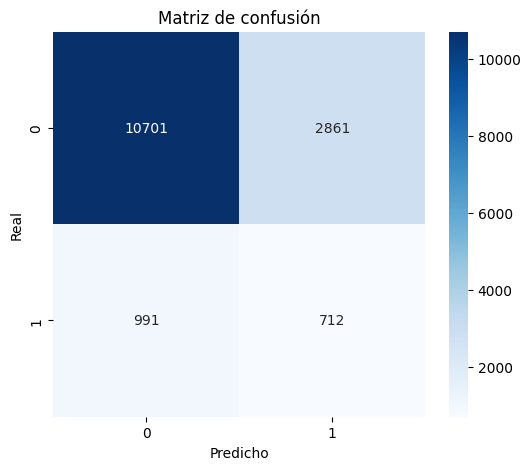

In [ ]:
cm = confusion_matrix(y_test,test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

La matriz de confusión muestra que el modelo clasifica correctamente 10.701 pacientes sin reingreso (verdaderos negativos) y 712 pacientes con reingreso (verdaderos positivos). Sin embargo, también genera 2.861 falsos positivos, es decir, pacientes identificados como de alto riesgo que finalmente no son reingresados, y 991 falsos negativos, correspondientes a pacientes que sí fueron reingresados pero que el modelo no logró detectar. En conjunto, estos resultados reflejan que el modelo prioriza la identificación de pacientes de riesgo, aceptando un número considerable de falsas alarmas para aumentar la capacidad de detección de casos reales.

## Curva ROC

La curva ROC representa el rendimiento del modelo para todos los posibles umbrales de clasificación.

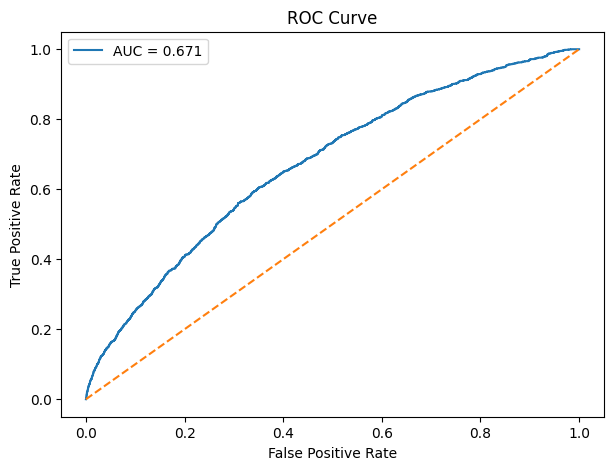

In [ ]:
fpr, tpr, _ = roc_curve(y_test,test_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

La curva ROC se sitúa claramente por encima de la diagonal que representa un clasificador aleatorio, obteniendo un AUC de 0.671. Esto indica que el modelo posee una capacidad discriminativa moderada para diferenciar entre pacientes que serán reingresados y aquellos que no lo serán. En términos prácticos, si se selecciona aleatoriamente un paciente que será reingresado y otro que no, el modelo asignará una puntuación de riesgo más alta al primero aproximadamente en un 67% de las ocasiones. Aunque el rendimiento está lejos de ser excelente, demuestra que el modelo captura patrones clínicos relevantes presentes en los datos.

## Curva Precision-Recall

Esta curva resulta especialmente útil en problemas con clases desbalanceadas como el presente caso.

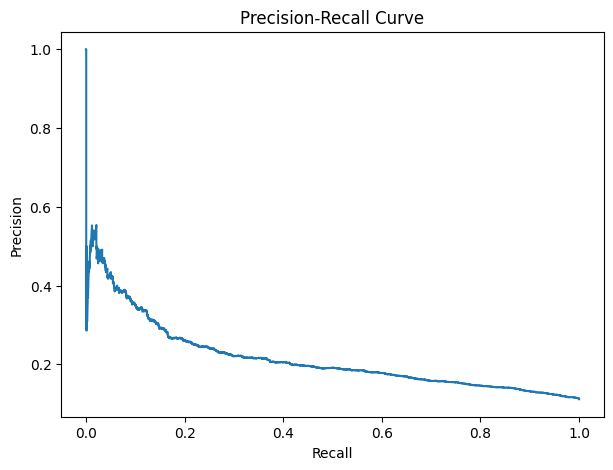

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test,test_prob)

plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

La curva Precision–Recall muestra el compromiso existente entre precisión y sensibilidad (recall) en un problema fuertemente desbalanceado como este. Se observa que para alcanzar valores elevados de recall es necesario aceptar precisiones relativamente bajas, lo que implica un aumento de falsos positivos. Conforme disminuye el recall, la precisión mejora ligeramente, aunque sin alcanzar valores muy elevados. Este comportamiento es habitual en modelos de predicción de reingresos hospitalarios, donde el objetivo principal suele ser identificar el mayor número posible de pacientes vulnerables, incluso a costa de generar algunas alertas innecesarias. La curva confirma que el modelo ofrece utilidad como herramienta de apoyo al cribado clínico, aunque no debe utilizarse como único criterio para la toma de decisiones médicas.

## Importancia de variables

Las variables relacionadas con complejidad clínica y utilización previa del sistema sanitario muestran generalmente la mayor capacidad predictiva.

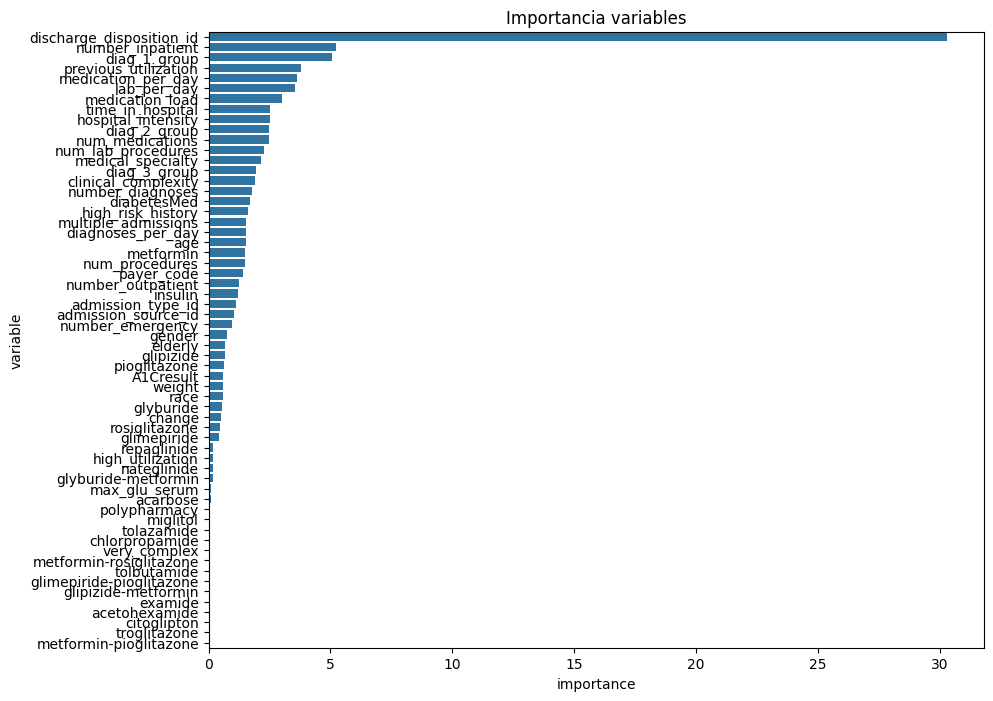

,variable,importance
5,discharge_disposition_id,30.294267
15,number_inpatient,5.209254
19,diag_1_group,5.042913
48,previous_utilization,3.807379
51,medication_per_day,3.630683
52,lab_per_day,3.537136
50,medication_load,3.000651
9,time_in_hospital,2.531142
49,hospital_intensity,2.519717
20,diag_2_group,2.483793


In [ ]:
importance_df = pd.DataFrame({ "variable": features,"importance":best_model.feature_importances_})

importance_df = importance_df.sort_values(by="importance",ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(data=importance_df,x="importance",y="variable")

plt.title("Importancia variables")

plt.show()

display(importance_df.head(20))

La gráfica muestra la importancia relativa que CatBoost asigna a cada variable durante el proceso de predicción. Se observa que discharge_disposition_id es, con diferencia, la variable más influyente, lo que sugiere que la forma en que finaliza el episodio hospitalario está estrechamente relacionada con la probabilidad de reingreso. A continuación destacan number_inpatient y previous_utilization, indicando que el historial previo de hospitalizaciones y la utilización anterior del sistema sanitario son factores clave para identificar pacientes con mayor riesgo. También aparecen entre las variables más relevantes medication_load, time_in_hospital, los grupos diagnósticos (diag_1_group, diag_2_group, diag_3_group) y variables relacionadas con el tratamiento farmacológico. En conjunto, el modelo parece apoyarse principalmente en indicadores de complejidad clínica, gravedad del paciente y uso previo de recursos sanitarios, mientras que muchas medicaciones específicas tienen una contribución muy reducida.

## SHAP

SHAP permite interpretar cómo contribuye cada variable a las predicciones individuales del modelo.

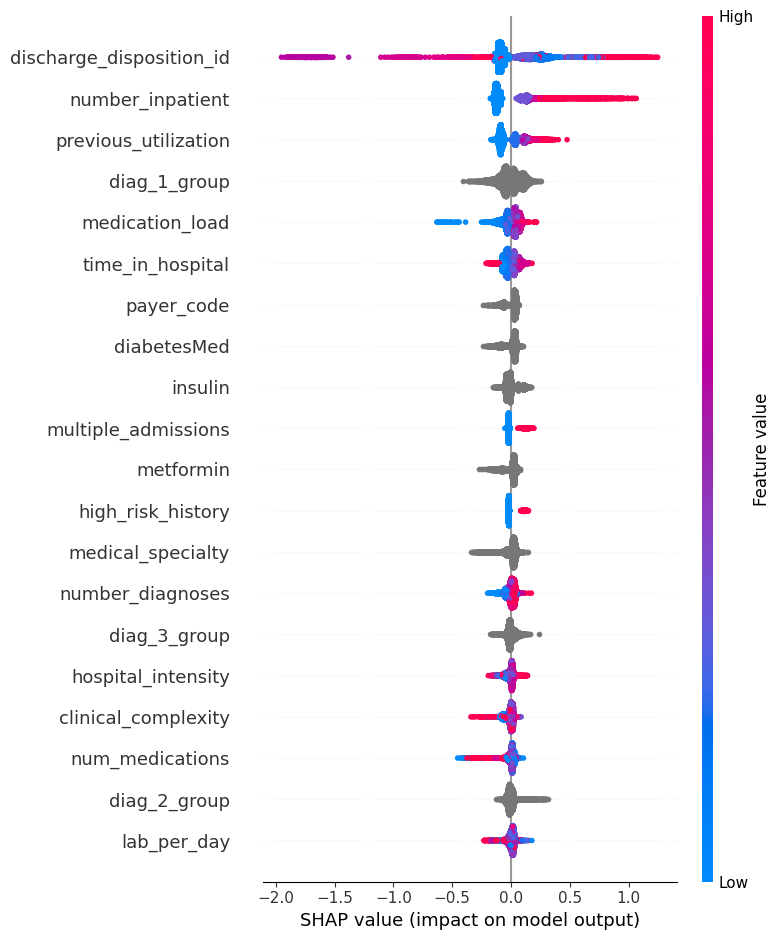

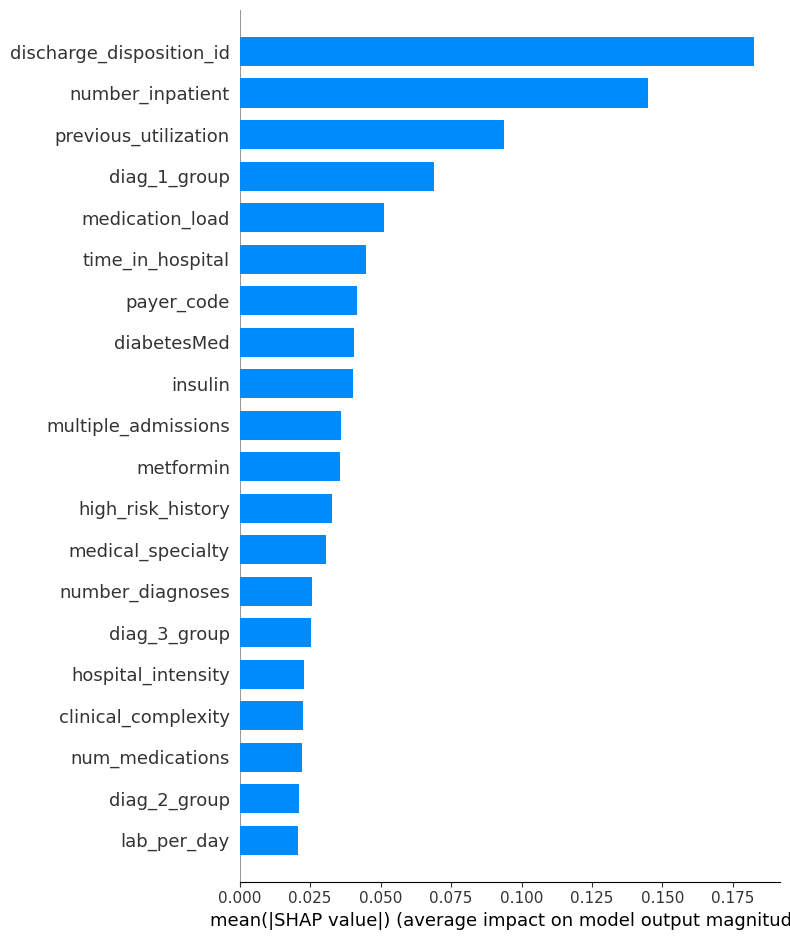

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values,X_test)

shap.summary_plot(shap_values,X_test,plot_type="bar")

La segunda gráfica muestra la importancia global calculada mediante SHAP, una medida más robusta e interpretable que la importancia interna del modelo. Los resultados confirman que discharge_disposition_id es la variable con mayor impacto promedio sobre las predicciones, seguida por number_inpatient y previous_utilization. Esto indica que el historial de ingresos previos y la frecuencia de utilización del sistema sanitario son los principales determinantes del riesgo de reingreso. Además, variables derivadas creadas durante el feature engineering, como medication_load, multiple_admissions, high_risk_history, hospital_intensity o clinical_complexity, aparecen entre las más importantes, lo que valida la utilidad de las nuevas características incorporadas al modelo. También se observa que factores relacionados con el tratamiento de la diabetes, como diabetesMed, insulin o metformin, aportan información relevante, aunque con menor peso que los antecedentes clínicos y hospitalarios. En general, la gráfica SHAP confirma que el modelo basa sus decisiones en variables clínicamente coherentes y proporciona evidencia de que el feature engineering realizado ha contribuido significativamente a la mejora del rendimiento predictivo.

## Predicción de un nuevo paciente

In [ ]:
nuevo_paciente = pd.DataFrame({

    "race":["Caucasian"],
    "gender":["Male"],
    "age":["[70-80)"],
    "weight":["?"],

    "admission_type_id":[1],
    "discharge_disposition_id":[1],
    "admission_source_id":[7],

    "payer_code":["MC"],
    "medical_specialty":["InternalMedicine"],

    "time_in_hospital":[7],
    "num_lab_procedures":[65],
    "num_procedures":[1],
    "num_medications":[24],

    "number_outpatient":[2],
    "number_emergency":[1],
    "number_inpatient":[3],

    "number_diagnoses":[9],

    "max_glu_serum":["None"],
    "A1Cresult":["Norm"],

    "diag_1_group":["Circulatory"],
    "diag_2_group":["Diabetes"],
    "diag_3_group":["Other"],

    "change":["Ch"],
    "diabetesMed":["Yes"],

    # medicaciones
    "metformin":["Steady"],
    "repaglinide":["No"],
    "nateglinide":["No"],
    "chlorpropamide":["No"],
    "glimepiride":["No"],
    "acetohexamide":["No"],
    "glipizide":["No"],
    "glyburide":["No"],
    "tolbutamide":["No"],
    "pioglitazone":["No"],
    "rosiglitazone":["No"],
    "acarbose":["No"],
    "miglitol":["No"],
    "troglitazone":["No"],
    "tolazamide":["No"],
    "examide":["No"],
    "citoglipton":["No"],
    "insulin":["Steady"],
    "glyburide-metformin":["No"],
    "glipizide-metformin":["No"],
    "glimepiride-pioglitazone":["No"],
    "metformin-rosiglitazone":["No"],
    "metformin-pioglitazone":["No"],

    # variables derivadas
    "clinical_complexity":[33],
    "previous_utilization":[6],
    "hospital_intensity":[9.29],
    "medication_load":[168],

    "medication_per_day":[3.43],
    "lab_per_day":[9.29],
    "diagnoses_per_day":[1.29],

    "polypharmacy":[1],
    "elderly":[1],

    "high_utilization":[1],
    "multiple_admissions":[1],

    "high_risk_history":[1],
    "very_complex":[1]

})

In [ ]:
riesgo = best_model.predict_proba(
    nuevo_paciente
)[:,1][0]

print(
    f"Probabilidad: {riesgo*100:.2f}%"
)

if riesgo >= best_threshold:
    print("Paciente ALTO RIESGO")
else:
    print("Paciente BAJO RIESGO")

Probabilidad: 38.88%
Paciente BAJO RIESGO


Tras introducir los datos clínicos del paciente en el modelo CatBoost entrenado, se ha obtenido una probabilidad estimada de reingreso hospitalario del 38.88%. Esta probabilidad representa el riesgo calculado por el modelo de que el paciente vuelva a ingresar en el hospital dentro del periodo considerado por el dataset.

Sin embargo, la clasificación final no depende únicamente de la probabilidad obtenida, sino también del threshold (umbral de decisión) seleccionado durante la fase de optimización del modelo. En este caso, la probabilidad del paciente (38.88%) se sitúa por debajo del umbral definido como óptimo para clasificar a un paciente como de alto riesgo, por lo que el sistema lo etiqueta como Paciente de Bajo Riesgo.

Desde un punto de vista clínico, aunque el paciente no sea clasificado como de alto riesgo, una probabilidad cercana al 40% no puede considerarse despreciable. El modelo indica que existen ciertos factores asociados a un posible reingreso, como el número de medicamentos prescritos, los diagnósticos registrados y los ingresos hospitalarios previos. Por tanto, el resultado debe interpretarse como una estimación de apoyo a la decisión médica y no como un diagnóstico definitivo.

In [ ]:
def predecir_paciente(best_model,
                      best_threshold,
                      paciente):

    riesgo = best_model.predict_proba(
        paciente
    )[:,1][0]

    print(
        f"Probabilidad reingreso: {riesgo*100:.2f}%"
    )

    if riesgo >= best_threshold:
        print("Paciente ALTO RIESGO")
    else:
        print("Paciente BAJO RIESGO")

    return riesgo

## Guardado del modelo

In [ ]:
#Guardar archivos
import joblib

joblib.dump( best_model, "modelo_diabetes_readmission.pkl")

joblib.dump(best_threshold, "best_threshold.pkl")

joblib.dump(features, "features.pkl")

joblib.dump(cat_features,"cat_features.pkl")

print("Archivos guardados")

Archivos guardados


In [ ]:
#Crear zipfile
import zipfile

with zipfile.ZipFile("modelo_streamlit.zip", "w") as z:

    z.write("modelo_diabetes_readmission.pkl")
    z.write("best_threshold.pkl")
    z.write("features.pkl")
    z.write("cat_features.pkl")

print("ZIP creado")

ZIP creado


In [ ]:
# Descargar zip file
from google.colab import files

files.download("modelo_streamlit.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **FASE 2: Construcción y validación del modelo predictivo**

El objetivo es transformar el modelo entrenado en la Parte 1 en una herramienta clínica interactiva capaz de:
- estimar riesgo de reingreso
- explicar el resultado
- generar recomendaciones
- asistir al profesional sanitario

## **Bloque A Fase 2: Carga del sistema y motor predictivo**

El objetivo es cargar los archivos .pkl y construir el motor que posteriormente utilizará Streamlit.

## Importación de librerías

En esta sección se importan las librerías necesarias para cargar el modelo entrenado y realizar predicciones sobre nuevos pacientes.

In [ ]:
import pandas as pd
import numpy as np

import joblib

from catboost import CatBoostClassifier

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Carga de archivos exportados

Se recuperan todos los objetos generados durante la Parte I. Esto permite desacoplar completamente el entrenamiento del modelo de su utilización posterior en la aplicación.

In [ ]:
best_model = joblib.load("modelo_diabetes_readmission.pkl")

best_threshold = joblib.load("best_threshold.pkl")

print("Threshold cargado:",best_threshold)
print("Modelo cargado.")

features = joblib.load("features.pkl")

print("Número variables:",len(features))

cat_features = joblib.load("cat_features.pkl")

print("Variables categóricas:",len(cat_features))

print("\nPrimeras variables:")

for f in features[:10]:

    print(f)

Threshold cargado: 0.55
Modelo cargado.
Número variables: 60
Variables categóricas: 36

Primeras variables:
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
payer_code
medical_specialty
time_in_hospital


## Información del sistema

Esta comprobación garantiza que todos los componentes necesarios para realizar predicciones se han cargado correctamente.

In [ ]:
print("\n================ SISTEMA =================")

print("Modelo:",type(best_model))

print("Threshold:",best_threshold)

print("Número variables:",len(features))

print("Variables categóricas:",len(cat_features))


================ SISTEMA =================
Modelo: <class 'catboost.core.CatBoostClassifier'>
Threshold: 0.55
Número variables: 60
Variables categóricas: 36


## Creación de paciente de ejemplo

Construir un paciente sintético compatible con el modelo.

In [ ]:
patient = {}

for feature in features:
  patient[feature] = np.nan
  patient["race"] = "Caucasian"
  patient["gender"] = "Male"
  patient["age"] = "[70-80)"
  patient["weight"] = "?"
  patient["admission_type_id"] = 1
  patient["discharge_disposition_id"] = 1
  patient["admission_source_id"] = 7
  patient["payer_code"] = "MC"
  patient["medical_specialty"] = "InternalMedicine"
  patient["time_in_hospital"] = 7
  patient["num_lab_procedures"] = 65
  patient["num_procedures"] = 1
  patient["num_medications"] = 24
  patient["number_outpatient"] = 2
  patient["number_emergency"] = 1
  patient["number_inpatient"] = 3
  patient["number_diagnoses"] = 9
  patient["max_glu_serum"] = "None"
  patient["A1Cresult"] = "Norm"
  patient["diag_1_group"] = "Circulatory"
  patient["diag_2_group"] = "Diabetes"
  patient["diag_3_group"] = "Other"
  patient["change"] = "Ch"
  patient["diabetesMed"] = "Yes"

medication_cols = [
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'acetohexamide',
    'glipizide',
    'glyburide',
    'tolbutamide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'troglitazone',
    'tolazamide',
    'examide',
    'citoglipton',
    'insulin',
    'glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

for med in medication_cols:
    patient[med] = "No"
    patient["metformin"] = "Steady"
    patient["insulin"] = "Steady"

## Feature engineering automático

In [ ]:
patient["clinical_complexity"] = ( patient["num_medications"] + patient["number_diagnoses"])

patient["previous_utilization"] = (patient["number_outpatient"]+patient["number_emergency"]+patient["number_inpatient"])

patient["hospital_intensity"] = (patient["num_lab_procedures"]+patient["num_procedures"])

patient["medication_load"] = (patient["num_medications"]*patient["number_diagnoses"])

patient["medication_per_day"] = (patient["num_medications"]/(patient["time_in_hospital"] + 1))

patient["lab_per_day"] = (patient["num_lab_procedures"]/(patient["time_in_hospital"] + 1))

patient["diagnoses_per_day"] = (patient["number_diagnoses"]/(patient["time_in_hospital"] + 1))

patient["polypharmacy"] = 1

patient["elderly"] = 1

patient["high_utilization"] = 1

patient["multiple_admissions"] = 1

patient["high_risk_history"] = 1

patient["very_complex"] = 1

## Convertir a dataframe

Se construye un registro completamente compatible con la estructura esperada por el modelo.

In [ ]:
patient_df = pd.DataFrame([patient])
print(patient_df.shape)
display(patient_df.head())

(1, 60)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,payer_code,medical_specialty,time_in_hospital,...,medication_load,medication_per_day,lab_per_day,diagnoses_per_day,polypharmacy,elderly,high_utilization,multiple_admissions,high_risk_history,very_complex
0,Caucasian,Male,[70-80),?,1,1,7,MC,InternalMedicine,7,...,216,3.0,8.125,1.125,1,1,1,1,1,1


## Predicción

El modelo devuelve una probabilidad de reingreso hospitalario que posteriormente se compara con el umbral óptimo calculado durante la fase de validación.

In [ ]:
risk = best_model.predict_proba(patient_df)[:,1][0]

print(f"\nProbabilidad: {risk*100:.2f}%")

if risk >= best_threshold:
    print("Paciente ALTO RIESGO")
else:
    print("Paciente BAJO RIESGO")


Probabilidad: 38.34%
Paciente BAJO RIESGO


## Función reutilizable

Esta función será la que usemos más adelante en Streamlit.

In [ ]:
def predict_patient(patient_df,model,threshold   ):

    risk = model.predict_proba(patient_df )[:,1][0]

    label = ("ALTO RIESGO"
        if risk >= threshold
        else
        "BAJO RIESGO"
    )

    return risk, label

In [ ]:
# Prueba

risk, label = predict_patient(patient_df,best_model,best_threshold)

print(risk)

print(label)

0.38337585193857
BAJO RIESGO


Se ha construido el núcleo funcional del sistema, permitiendo cargar el modelo entrenado, generar pacientes compatibles con la estructura original de datos y obtener predicciones de riesgo de reingreso. Este motor predictivo constituirá la base sobre la que se desarrollará la aplicación interactiva en Streamlit en los siguientes bloques.

## **Bloque B Fase 2: Explainer shap**

En este bloque se incorpora un sistema de explicabilidad basado en SHAP capaz de justificar las predicciones realizadas por el modelo CatBoost. Gracias a esta técnica, es posible identificar los factores que aumentan o disminuyen el riesgo de reingreso de cada paciente, proporcionando transparencia al sistema y facilitando su interpretación por parte de profesionales sanitarios. Esta funcionalidad constituye uno de los elementos clave del futuro asistente clínico inteligente.

In [ ]:
# Función SHAP reutilizable
def explain_patient(patient_df,model):

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(patient_df)

    shap_df = pd.DataFrame({ "variable":patient_df.columns, "shap_value":shap_values[0]})

    shap_df["abs_shap"] = (shap_df["shap_value"].abs())

    shap_df = shap_df.sort_values(by="abs_shap",ascending=False)

    return shap_df

In [ ]:
# Prueba
explanation = explain_patient(patient_df,best_model)
display(explanation.head(10))

,variable,shap_value,abs_shap
3,weight,-0.629416,0.629416
15,number_inpatient,0.289502,0.289502
48,previous_utilization,0.199028,0.199028
58,high_risk_history,0.122970,0.122970
57,multiple_admissions,0.089359,0.089359
18,A1Cresult,-0.085214,0.085214
17,max_glu_serum,-0.067400,0.067400
50,medication_load,0.064015,0.064015
21,diag_3_group,-0.057706,0.057706
19,diag_1_group,-0.055755,0.055755


## Bloque 3 Fase 2: AI Clinical Assistant

El objetivo es convertir una predicción numérica (ex: Riesgo = 38.34%) en algo que un médico pueda interpretar rápidamente:

## Importar librerías

In [ ]:
import pandas as pd
import numpy as np

##Extraer top 5 variables shap

Las cinco variables con mayor impacto absoluto se utilizarán como base para construir las explicaciones clínicas automáticas.

In [ ]:
top5 = explanation.head(5)
display(top5)

,variable,shap_value,abs_shap
3,weight,-0.629416,0.629416
15,number_inpatient,0.289502,0.289502
48,previous_utilization,0.199028,0.199028
58,high_risk_history,0.122970,0.122970
57,multiple_admissions,0.089359,0.089359


## Función de nivel de riesgo, factores de riesgo y protectores

In [ ]:
# Nivel de riesgo
def risk_level(risk,threshold):

    if risk < threshold * 0.5:
        return "BAJO"

    elif risk < threshold:
        return "INTERMEDIO"

    else:
        return "ALTO"

# Factores de riesgo
risk_factors = explanation[explanation["shap_value"] > 0]
display(risk_factors.head(10))

# Factores protectores
protective_factors = explanation[explanation["shap_value"] < 0]
display(protective_factors.head(10))

,variable,shap_value,abs_shap
15,number_inpatient,0.289502,0.289502
48,previous_utilization,0.199028,0.199028
58,high_risk_history,0.122970,0.122970
57,multiple_admissions,0.089359,0.089359
50,medication_load,0.064015,0.064015
34,rosiglitazone,0.035521,0.035521
9,time_in_hospital,0.034564,0.034564
14,number_emergency,0.033924,0.033924
7,payer_code,0.024478,0.024478
13,number_outpatient,0.017275,0.017275


,variable,shap_value,abs_shap
3,weight,-0.629416,0.629416
18,A1Cresult,-0.085214,0.085214
17,max_glu_serum,-0.067400,0.067400
21,diag_3_group,-0.057706,0.057706
19,diag_1_group,-0.055755,0.055755
53,diagnoses_per_day,-0.045874,0.045874
42,glyburide-metformin,-0.041721,0.041721
4,admission_type_id,-0.039282,0.039282
12,num_medications,-0.033694,0.033694
35,acarbose,-0.029278,0.029278


## Generador de recomendaciones simples

In [ ]:

def generate_recommendations(patient_df):

    recs = []

    if patient_df["number_inpatient"].iloc[0] >= 2:
        recs.append(
            "Realizar seguimiento precoz tras el alta."
        )

    if patient_df["num_medications"].iloc[0] >= 15:
        recs.append(
            "Revisar tratamiento farmacológico."
        )

    if patient_df["number_diagnoses"].iloc[0] >= 8:
        recs.append(
            "Priorizar control de comorbilidades."
        )

    if patient_df["time_in_hospital"].iloc[0] >= 7:
        recs.append(
            "Programar revisión clínica temprana."
        )

    if len(recs) == 0:
        recs.append(
            "Mantener seguimiento habitual."
        )

    return recs

In [ ]:
recommendations = generate_recommendations(patient_df)

recommendations

['Realizar seguimiento precoz tras el alta.',
 'Revisar tratamiento farmacológico.',
 'Priorizar control de comorbilidades.',
 'Programar revisión clínica temprana.']

## Generador del informe clínico

In [ ]:
variable_names = {

    "number_inpatient":
        "Ingresos hospitalarios previos",

    "previous_utilization":
        "Utilización previa del sistema sanitario",

    "high_risk_history":
        "Historial clínico de riesgo",

    "multiple_admissions":
        "Múltiples ingresos previos",

    "num_medications":
        "Número de medicamentos",

    "number_diagnoses":
        "Número de diagnósticos",

    "time_in_hospital":
        "Duración de la hospitalización",

    "A1Cresult":
        "Resultado HbA1c"

}

# Función generar informe
def generate_clinical_report(patient_df,risk,label,explanation):

    report = []

    # Encabezado
    report.append("INFORME CLÍNICO AUTOMÁTICO")
    report.append("=" * 50)

    # Resultado principal
    report.append(f"\nProbabilidad estimada de reingreso: {risk*100:.2f}%")
    report.append(f"Clasificación del modelo: {label}")
    report.append(f"Nivel clínico estimado: {risk_level(risk,best_threshold)}")

    # Datos clínicos principales
    report.append("\nDATOS CLÍNICOS RELEVANTES")
    report.append("-" * 30)
    report.append(f"Días hospitalizado: {patient_df['time_in_hospital'].iloc[0]}")
    report.append(f"Número medicamentos: {patient_df['num_medications'].iloc[0]}")
    report.append(f"Ingresos previos: {patient_df['number_inpatient'].iloc[0]}")
    report.append(f"Número diagnósticos: {patient_df['number_diagnoses'].iloc[0]}")

    # Factores más influyentes
    report.append("\nFACTORES MÁS INFLUYENTES")
    report.append("-" * 30)

    # Variables que no queremos mostrar

    excluded_vars = ["weight","payer_code"]

    valid_explanation = explanation[~explanation["variable"].isin(excluded_vars)]

    for _, row in valid_explanation.head(5).iterrows():

        report.append(
            f"{variable_names.get(row["variable"],row["variable"])} "
            f"(impacto SHAP = {row['shap_value']:.4f})"
        )

    # Recomendaciones
    report.append("\nRECOMENDACIONES")
    report.append( "-" * 30)
    recs = generate_recommendations(patient_df)

    for rec in recs:
        report.append(f"• {rec}")

    # Conclusión

    if risk >= best_threshold:

        conclusion = """
    El paciente presenta un perfil clínico compatible con un riesgo elevado de reingreso hospitalario.
    Se recomienda seguimiento estrecho tras el alta y revisión individualizada de los principales factores de riesgo.
        """

    else:

        conclusion = """
    El paciente no supera el umbral establecido para ser considerado de alto riesgo de reingreso. Sin embargo, presenta diversos factores clínicos asociados
    a una mayor probabilidad de rehospitalización, especialmente relacionados con ingresos previos, utilización frecuente de recursos sanitarios y
    elevada complejidad clínica. Se recomienda mantener un seguimiento adecuado tras el alta.
        """
    report.append("\nCONCLUSIÓN")
    report.append("-" * 30)
    report.append(conclusion)
    return "\n".join(report)

In [ ]:
# Llamada a la función
clinical_report = generate_clinical_report(patient_df,risk,label,explanation)

# Visualización mejorada
print("\n")
print("=" * 60)
print("🤖 AI DIABETES CLINICAL ASSISTANT")
print("=" * 60)
print("\n")
print(clinical_report)
print("\n")
print("=" * 60)



🤖 AI DIABETES CLINICAL ASSISTANT


INFORME CLÍNICO AUTOMÁTICO

Probabilidad estimada de reingreso: 38.34%
Clasificación del modelo: BAJO RIESGO
Nivel clínico estimado: INTERMEDIO

DATOS CLÍNICOS RELEVANTES
------------------------------
Días hospitalizado: 7
Número medicamentos: 24
Ingresos previos: 3
Número diagnósticos: 9

FACTORES MÁS INFLUYENTES
------------------------------
Ingresos hospitalarios previos (impacto SHAP = 0.2895)
Utilización previa del sistema sanitario (impacto SHAP = 0.1990)
Historial clínico de riesgo (impacto SHAP = 0.1230)
Múltiples ingresos previos (impacto SHAP = 0.0894)
Resultado HbA1c (impacto SHAP = -0.0852)

RECOMENDACIONES
------------------------------
• Realizar seguimiento precoz tras el alta.
• Revisar tratamiento farmacológico.
• Priorizar control de comorbilidades.
• Programar revisión clínica temprana.

CONCLUSIÓN
------------------------------

    El paciente no supera el umbral establecido para ser considerado de alto riesgo de reingreso. Si

In [ ]:
with open("clinical_report.txt", "w", encoding="utf-8") as f:
    f.write(clinical_report)

print("Informe guardado correctamente.")

from google.colab import files

files.download("clinical_report.txt")

Informe guardado correctamente.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Carga de ficheros

In [ ]:
#Descomprimir zip

import zipfile

with zipfile.ZipFile(
    "/content/modelo_streamlit.zip",
    "r"
) as zip_ref:

    zip_ref.extractall(
        "/content/modelo_streamlit"
    )

print("ZIP descomprimido correctamente")

ZIP descomprimido correctamente


In [ ]:
# Comprobamos que existe
import os

print(
    os.listdir("/content/modelo_streamlit")
)

['cat_features.pkl', 'features.pkl', 'modelo_diabetes_readmission.pkl', 'best_threshold.pkl']


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [ ]:
import catboost
import joblib

best_model = joblib.load(
    "/content/modelo_streamlit/modelo_diabetes_readmission.pkl"
)

best_threshold = joblib.load(
    "/content/modelo_streamlit/best_threshold.pkl"
)

features = joblib.load(
    "/content/modelo_streamlit/features.pkl"
)

cat_features = joblib.load(
    "/content/modelo_streamlit/cat_features.pkl"
)

print("Sistema cargado correctamente.")

Sistema cargado correctamente.
